<a href="https://colab.research.google.com/github/k2herat/DL2/blob/hw8/Almetov_hw8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:

import math
import time
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [25]:

def vanilla_attention(Q, K, V):
    d = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d)
    attn = torch.softmax(scores, dim=-1)
    return attn @ V

def elsa_attention(Q, K, V, block_size=64):
    B, n, d = Q.shape
    scale = 1.0 / math.sqrt(d)
    m = torch.full((B, n, 1), float('-inf'), device=Q.device, dtype=Q.dtype)
    l = torch.zeros((B, n, 1), device=Q.device, dtype=Q.dtype)
    o = torch.zeros((B, n, d), device=Q.device, dtype=Q.dtype)
    for start in range(0, n, block_size):
        end = min(start + block_size, n)
        Kb = K[:, start:end, :]
        Vb = V[:, start:end, :]
        s = (Q @ Kb.transpose(-2, -1)) * scale
        m_block = s.max(dim=-1, keepdim=True).values
        m_new = torch.maximum(m, m_block)
        alpha = torch.exp(m - m_new)
        p = torch.exp(s - m_new)
        l = alpha * l + p.sum(dim=-1, keepdim=True)
        o = alpha * o + p @ Vb
        m = m_new
    return o / l

def linear_attention(Q, K, V):
    d = Q.size(-1)
    scale = 1.0 / math.sqrt(d)
    Qp = F.elu(Q * scale) + 1.0
    Kp = F.elu(K * scale) + 1.0
    KV = Kp.transpose(-2, -1) @ V
    Z = Kp.sum(dim=1, keepdim=True)
    num = Qp @ KV
    den = (Qp * Z).sum(dim=-1, keepdim=True).clamp(min=1e-6)
    return num / den

In [26]:

def load_mnist_as_sequences(batch_size=64, max_train=None):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_set  = datasets.MNIST('./data', train=False, download=True, transform=transform)

    # Преобразуем каждое изображение в последовательность строк: [28, 28]
    # Возвращаем тензор [N, seq_len=28, d_in=28]
    def to_sequence(tensor):
        # tensor: [1, 28, 28] -> [28, 28]
        return tensor.squeeze(0)  # (28, 28)

    X_train = torch.stack([to_sequence(img) for img, _ in train_set])  # [N, 28, 28]
    y_train = torch.tensor([label for _, label in train_set], dtype=torch.long)
    X_test = torch.stack([to_sequence(img) for img, _ in test_set])
    y_test = torch.tensor([label for _, label in test_set], dtype=torch.long)

    if max_train is not None:
        X_train, y_train = X_train[:max_train], y_train[:max_train]
    if max_train is not None:
        X_test, y_test = X_test[:1000], y_test[:1000]  # ограничим тест для скорости

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

train_loader, test_loader = load_mnist_as_sequences(batch_size=64, max_train=3000)
print(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')
print(f'Example input shape: {next(iter(train_loader))[0].shape}')  # [B, 28, 28]

Train batches: 47, Test batches: 16
Example input shape: torch.Size([64, 28, 28])


In [27]:

class SeqAttnClassifier(nn.Module):
    def __init__(self, attn_fn, d_in=28, d_model=64, n_classes=10, seq_len=28):
        super().__init__()
        self.attn_fn = attn_fn
        self.seq_len = seq_len
        self.in_proj = nn.Linear(d_in, d_model)
        self.pos = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4*d_model),
            nn.GELU(),
            nn.Linear(4*d_model, d_model)
        )
        self.cls = nn.Linear(d_model, n_classes)

    def forward(self, x):
        # x: [B, seq_len, d_in]
        h = self.in_proj(x) + self.pos      # [B, seq_len, d_model]
        q, k, v = self.qkv(h).chunk(3, dim=-1)
        a = self.attn_fn(q, k, v)           # [B, seq_len, d_model]
        h = self.norm1(h + self.out_proj(a))
        h = self.norm2(h + self.ffn(h))
        h = h.mean(dim=1)                   # Global avg pooling
        return self.cls(h)

In [28]:

def train_and_eval(attn_fn, name, epochs=8, lr=3e-3):
    model = SeqAttnClassifier(attn_fn).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    start_time = time.time()
    for epoch in range(epochs):
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"{name} | Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")
    train_time = time.time() - start_time

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    acc = correct / total
    print(f"{name} | Test acc: {acc:.4f} | Time: {train_time:.2f}s")
    return acc, train_time


=== Training vanilla ===
vanilla | Epoch 1/20 | Loss: 1.8208
vanilla | Epoch 2/20 | Loss: 1.2962
vanilla | Epoch 3/20 | Loss: 0.9335
vanilla | Epoch 4/20 | Loss: 0.6907
vanilla | Epoch 5/20 | Loss: 0.4827
vanilla | Epoch 6/20 | Loss: 0.3743
vanilla | Epoch 7/20 | Loss: 0.3242
vanilla | Epoch 8/20 | Loss: 0.2661
vanilla | Epoch 9/20 | Loss: 0.2283
vanilla | Epoch 10/20 | Loss: 0.1901
vanilla | Epoch 11/20 | Loss: 0.1751
vanilla | Epoch 12/20 | Loss: 0.1422
vanilla | Epoch 13/20 | Loss: 0.1339
vanilla | Epoch 14/20 | Loss: 0.1091
vanilla | Epoch 15/20 | Loss: 0.0796
vanilla | Epoch 16/20 | Loss: 0.0816
vanilla | Epoch 17/20 | Loss: 0.0814
vanilla | Epoch 18/20 | Loss: 0.1004
vanilla | Epoch 19/20 | Loss: 0.0782
vanilla | Epoch 20/20 | Loss: 0.0518
vanilla | Test acc: 0.9280 | Time: 3.40s

=== Training ELSA ===
ELSA | Epoch 1/20 | Loss: 1.8035
ELSA | Epoch 2/20 | Loss: 1.2946
ELSA | Epoch 3/20 | Loss: 0.9248
ELSA | Epoch 4/20 | Loss: 0.6652
ELSA | Epoch 5/20 | Loss: 0.4651
ELSA | Epoch 6

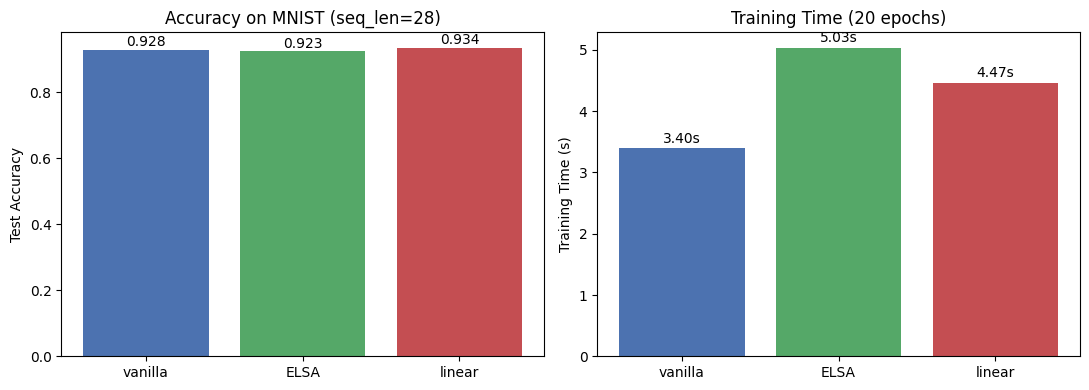

In [29]:

attn_methods = {
    'vanilla': vanilla_attention,
    'ELSA': lambda Q,K,V: elsa_attention(Q,K,V, block_size=16),
    'linear': linear_attention
}

quality_results = []
for name, fn in attn_methods.items():
    print(f"\n=== Training {name} ===")
    acc, t = train_and_eval(fn, name, epochs=20)
    quality_results.append((name, acc, t))


names = [r[0] for r in quality_results]
accs = [r[1] for r in quality_results]
times = [r[2] for r in quality_results]

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].bar(names, accs, color=['#4C72B0','#55A868','#C44E52'])
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Accuracy on MNIST (seq_len=28)')
for i, a in enumerate(accs):
    axes[0].text(i, a+0.01, f'{a:.3f}', ha='center')
axes[1].bar(names, times, color=['#4C72B0','#55A868','#C44E52'])
axes[1].set_ylabel('Training Time (s)')
axes[1].set_title('Training Time (20 epochs)')
for i, t in enumerate(times):
    axes[1].text(i, t*1.02, f'{t:.2f}s', ha='center')
plt.tight_layout()
plt.show()

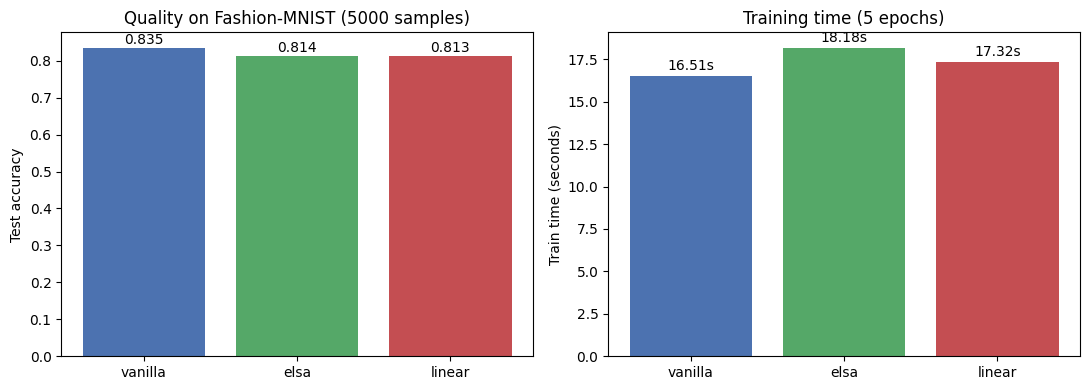

In [30]:
names = [r[0] for r in results]
accs  = [r[1] for r in results]
times = [r[2] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(names, accs, color=['#4C72B0', '#55A868', '#C44E52'])
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Quality on Fashion-MNIST (5000 samples)')
for i, a in enumerate(accs):
    axes[0].text(i, a + 0.01, f'{a:.3f}', ha='center')

axes[1].bar(names, times, color=['#4C72B0', '#55A868', '#C44E52'])
axes[1].set_ylabel('Train time (seconds)')
axes[1].set_title('Training time (5 epochs)')
for i, t in enumerate(times):
    axes[1].text(i, t * 1.02, f'{t:.2f}s', ha='center')

plt.tight_layout()
plt.show()

In [31]:

def benchmark_attention(attn_fn, seq_lens, B=2, d=64, device='cuda', n_warmup=2, n_iter=5):
    latencies = []
    for n in seq_lens:
        Q = torch.randn(B, n, d, device=device)
        K = torch.randn(B, n, d, device=device)
        V = torch.randn(B, n, d, device=device)
        # Warmup
        for _ in range(n_warmup):
            _ = attn_fn(Q, K, V)
        if device == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n_iter):
            out = attn_fn(Q, K, V)
        if device == 'cuda':
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        lat_ms = (t1 - t0) / n_iter * 1000
        latencies.append(lat_ms)
        print(f'n={n:5d} | latency={lat_ms:7.2f} ms')
    return latencies

seq_lens = [32, 64, 128, 256, 512, 1024]  # различные длины
print("Benchmarking vanilla...")
vanilla_lat = benchmark_attention(vanilla_attention, seq_lens)
print("\nBenchmarking ELSA (block_size=64)...")
elsa_lat = benchmark_attention(lambda Q,K,V: elsa_attention(Q,K,V,block_size=64), seq_lens)
print("\nBenchmarking linear...")
linear_lat = benchmark_attention(linear_attention, seq_lens)

Benchmarking vanilla...
n=   32 | latency=   0.20 ms
n=   64 | latency=   0.29 ms
n=  128 | latency=   0.11 ms
n=  256 | latency=   0.18 ms
n=  512 | latency=   0.20 ms
n= 1024 | latency=   0.53 ms

Benchmarking ELSA (block_size=64)...
n=   32 | latency=   0.32 ms
n=   64 | latency=   0.35 ms
n=  128 | latency=   0.78 ms
n=  256 | latency=   1.80 ms
n=  512 | latency=   4.91 ms
n= 1024 | latency=   4.21 ms

Benchmarking linear...
n=   32 | latency=   0.24 ms
n=   64 | latency=   0.21 ms
n=  128 | latency=   0.21 ms
n=  256 | latency=   0.21 ms
n=  512 | latency=   0.22 ms
n= 1024 | latency=   0.26 ms


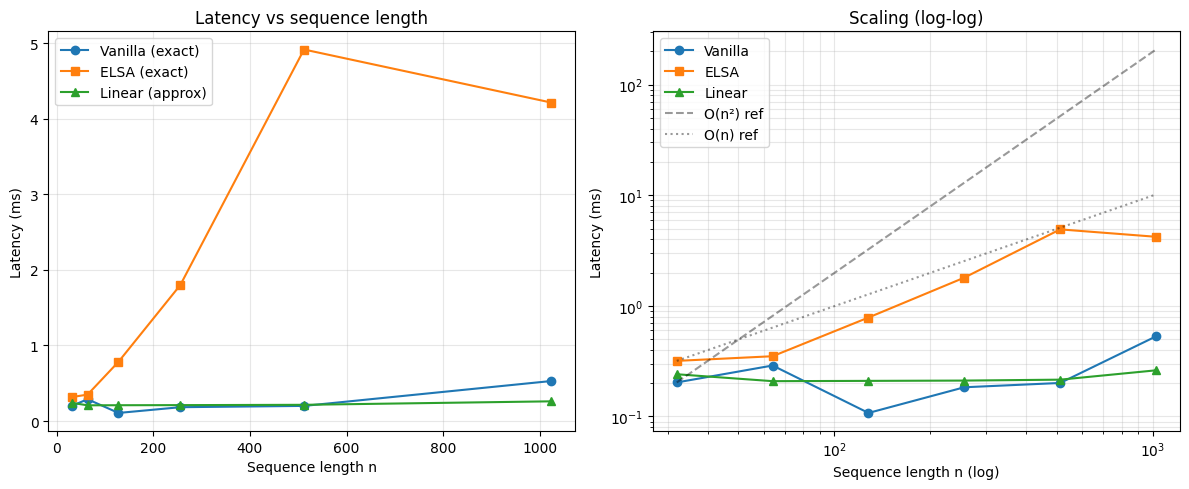

In [32]:

plt.figure(figsize=(12,5))

# Линейный график
plt.subplot(1,2,1)
plt.plot(seq_lens, vanilla_lat, 'o-', label='Vanilla (exact)')
plt.plot(seq_lens, elsa_lat, 's-', label='ELSA (exact)')
plt.plot(seq_lens, linear_lat, '^-', label='Linear (approx)')
plt.xlabel('Sequence length n')
plt.ylabel('Latency (ms)')
plt.title('Latency vs sequence length')
plt.grid(True, alpha=0.3)
plt.legend()

# Log-log график с референсными линиями O(n) и O(n²)
plt.subplot(1,2,2)
plt.loglog(seq_lens, vanilla_lat, 'o-', label='Vanilla')
plt.loglog(seq_lens, elsa_lat, 's-', label='ELSA')
plt.loglog(seq_lens, linear_lat, '^-', label='Linear')
# Эталонные прямые
ns = np.array(seq_lens)
ref_n2 = vanilla_lat[0] * (ns / ns[0])**2
ref_n = elsa_lat[0] * (ns / ns[0])
plt.loglog(seq_lens, ref_n2, 'k--', alpha=0.4, label='O(n²) ref')
plt.loglog(seq_lens, ref_n, 'k:', alpha=0.4, label='O(n) ref')
plt.xlabel('Sequence length n (log)')
plt.ylabel('Latency (ms)')
plt.title('Scaling (log-log)')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

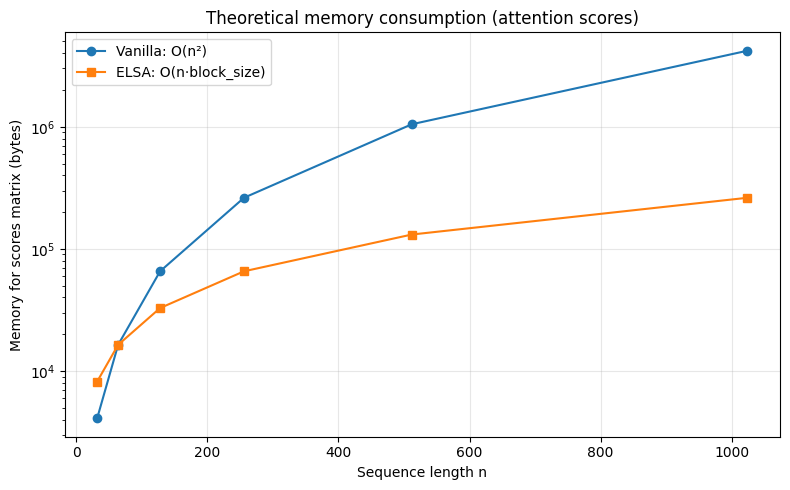

In [33]:

bytes_per_float = 4  # float32
def matrix_memory(n, d, block_size=None):
    if block_size is None:  # vanilla: хранит матрицу n×n
        return n * n * bytes_per_float
    else:  # ELSA: хранит блок n×block_size и дополнительно массивы m,l,o (n×1) и т.д.
        # упрощённо: основной буфер ~ n * block_size
        return n * block_size * bytes_per_float

vanilla_mem = [matrix_memory(n, 64) for n in seq_lens]
elsa_mem = [matrix_memory(n, 64, block_size=64) for n in seq_lens]

plt.figure(figsize=(8,5))
plt.plot(seq_lens, vanilla_mem, 'o-', label='Vanilla: O(n²)')
plt.plot(seq_lens, elsa_mem, 's-', label='ELSA: O(n·block_size)')
plt.xlabel('Sequence length n')
plt.ylabel('Memory for scores matrix (bytes)')
plt.title('Theoretical memory consumption (attention scores)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Вывод:

По точности: Linear показал наивысшую точность. Предположу, что это из-за особенностей датасета

По времени: на коротких последовательностях (Fashion‑MNIST, длина 28) Vanilla быстрее (16.5 с), ELSA медленнее всех (18.2 с).

По памяти: на длинных последовательностях ELSA радикально экономит память -- линейный рост, против квадратичного у Vanilla.
